# Практична робота №3 — Машинне навчання
**Тема:** Дослідження ефективності TF-IDF зважених ембеддингів для детекції текстів, згенерованих великими мовними моделями  
**Виконала:** Цюрпіта Діана, ФЕІ-44

**Мета:** Я дослідила, як метод агрегації FastText-векторів впливає на розпізнавання текстів AI та Human. Я порівняла Mean Pooling і TF-IDF Weighted Mean для SVM (RBF), Logistic Regression та KNN, проаналізувала геометрію векторного простору.

**Джерело:** `ML-Practice-3.pdf`, лекції `machine_learning_3.ipynb` і `machine_learning_4.ipynb`. Результати та висновки нижче формуються після виконання коду, а не вигадуються наперед.

> **Перед запуском:** покласти оригінальний CSV датасету **AI vs Human Text Classification Dataset 2026 (Kaggle)** у папку з цим Notebook або в підпапку `data`. Якщо CSV ще немає, Notebook зупиниться на етапі завантаження з чіткою підказкою. Потрібен інтернет для встановлення пакетів та `en_core_web_sm` під час першого запуску.

## Підготовка середовища
Я встановила потрібні бібліотеки та мовну модель spaCy. Якщо пакети вже встановлені, комірку можна пропустити.

In [1]:
# Я встановила бібліотеки для обробки текстів, ембеддингів та графіків.
%pip install -q numpy pandas matplotlib seaborn scipy scikit-learn gensim spacy tqdm
!python -m spacy download en_core_web_sm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.3/12.8 MB 11.2 MB/s eta 0:00:02
     --------- ------------------------------ 3.1/12.8 MB 9.2 MB/s eta 0:00:02
     --------------- ------------------------ 5.0/12.8 MB 9.1 MB/s eta 0:00:01
     ---------------------- ----------------- 7.3/12.8 MB 9.6 MB/s eta 0:00:01
     --------------------------- ------------ 8.9/12.8 MB 9.2 MB/s eta 0:00:01
     -------------------------------- ------- 10.5/12.8 MB 9.0 MB/s eta 0:00:01
     ------------------------------------- -- 12.1/12.8 MB 8.9 MB/s eta 0:00:01
     ---------------------------------------  12.6/12.8 MB 8.5 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 7.7 MB/s eta 0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Я імпортувала бібліотеки й зафіксувала seed для відтворюваності.
import re, os, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from gensim.models import FastText
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)
plt.rcParams['figure.figsize'] = (9, 5)
print('Бібліотеки імпортовані.')

Бібліотеки імпортовані.


## Етап 1. Завантаження та первинний аналіз
Я перевірила структуру даних, баланс класів, пропуски, дублікати, порожні та дуже короткі тексти. **Важливо:** дублікати видаляю до поділу, щоб однакові тексти не потрапили одночасно до навчання і тестування.

In [3]:
# Я знайшла CSV у папці Notebook або data/ та перевірила його структуру.
DATA_PATH = None  # За потреби: r'C:\Users\User\Downloads\dataset.csv'
if DATA_PATH is None:
    candidates = sorted(list(Path('.').glob('*.csv')) + list(Path('data').glob('*.csv')))
    if len(candidates) == 0:
        raise FileNotFoundError('Поклади CSV із Kaggle поряд із Notebook або у папку data/ і запусти знову.')
    if len(candidates) > 1:
        print('Знайдено декілька CSV:', [str(p) for p in candidates])
        raise ValueError('Укажи точний шлях до потрібного CSV у змінній DATA_PATH.')
    DATA_PATH = str(candidates[0])
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print('Файл:', DATA_PATH, '| Розмір:', df_raw.shape)
print('Колонки:', df_raw.columns.tolist())
display(df_raw.head(3))
display(df_raw.isna().sum().to_frame('Пропуски'))

Файл: ai_vs_human_text_2026.csv | Розмір: (2000, 9)
Колонки: ['text_id', 'label', 'source_model', 'domain', 'text_content', 'topic_hint', 'word_count', 'avg_sentence_length', 'generation_method']


,text_id,label,source_model,domain,text_content,topic_hint,word_count,avg_sentence_length,generation_method
0,TXT_0001,human,human,social,can we talk about gene editing ethics for a se...,gene editing ethics,27,13.5,template+human_variation
1,TXT_0002,human,human,social,update on election integrity concerns: it's co...,election integrity concerns,20,10.0,template+human_variation
2,TXT_0003,ai,gemini-2.0,news,Analysts are closely watching developments rel...,climate change adaptation strategies,39,13.0,style_simulation


,Пропуски
text_id,0
label,0
source_model,0
domain,0
text_content,0
topic_hint,0
word_count,0
avg_sentence_length,0
generation_method,0


In [5]:
# Я визначила назви текстової колонки та міток, не припускаючи структуру CSV без перевірки.
TEXT_COL = 'text_content'
LABEL_COL = 'label'
text_candidates = ['text', 'content', 'essay', 'article', 'response', 'generated_text']
label_candidates = ['label', 'class', 'generated', 'source', 'is_ai', 'target', 'author']
cols = {str(c).lower().strip(): c for c in df_raw.columns}
TEXT_COL = TEXT_COL or next((cols[x] for x in text_candidates if x in cols), None)
LABEL_COL = LABEL_COL or next((cols[x] for x in label_candidates if x in cols and cols[x] != TEXT_COL), None)
if TEXT_COL is None or LABEL_COL is None:
    raise ValueError('Не вдалося автоматично знайти колонки. Укажи TEXT_COL і LABEL_COL вручну. Колонки: ' + str(df_raw.columns.tolist()))
print('Текст:', TEXT_COL, '| Клас:', LABEL_COL)
print('Початкові класи:')
print(df_raw[LABEL_COL].value_counts(dropna=False).head(20))
print('Повні дублікати:', df_raw.duplicated().sum())
print('Дублікати текстів:', df_raw[TEXT_COL].duplicated().sum())

Текст: text_content | Клас: label
Початкові класи:
label
human    1334
ai        666
Name: count, dtype: int64
Повні дублікати: 0
Дублікати текстів: 1034


Тексти коротші за 5 слів: 0
Після очищення: (966, 4)


,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
0,579.0,36.3,9.4,19.0,27.0,36.0,44.0,52.0
1,387.0,37.9,7.0,23.0,35.0,39.0,44.0,50.0


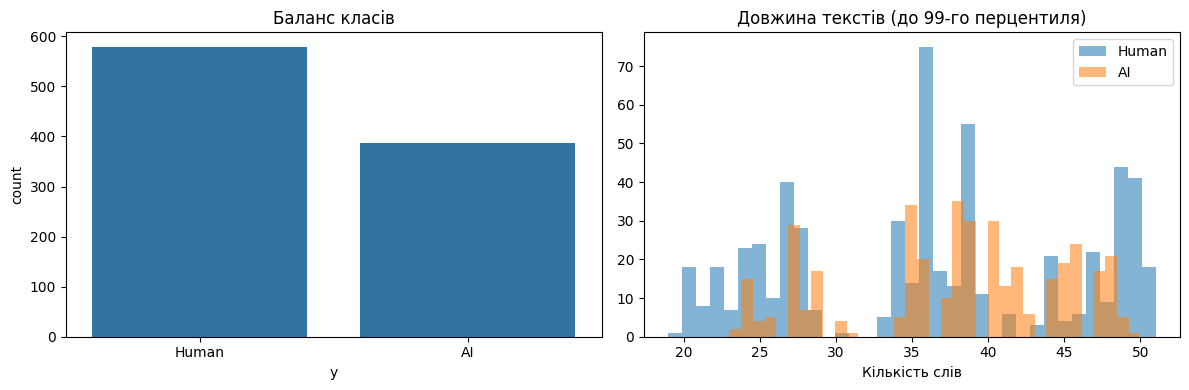

Мій висновок: частка AI = 40.06 %; медіанна довжина Human = 36.0 , AI = 39.0


In [6]:
# Я очистила некоректні записи та перевірила, що залишилися саме два класи.
df = df_raw[[TEXT_COL, LABEL_COL]].rename(columns={TEXT_COL:'text', LABEL_COL:'label'}).copy()
df = df.dropna(subset=['text','label'])
df['text'] = df['text'].astype(str).str.strip()
df = df[df['text'].str.len() > 0].drop_duplicates(subset=['text']).copy()

def normalize_label(value):
    s = str(value).strip().lower()
    if s in {'0', '0.0', 'human', 'human-written', 'human written', 'real', 'person', 'human_text'}: return 0
    if s in {'1', '1.0', 'ai', 'ai-generated', 'ai generated', 'generated', 'machine', 'llm', 'ai_text'}: return 1
    return np.nan

df['y'] = df['label'].map(normalize_label)
if df['y'].isna().any():
    print('Невідомі позначення:', df.loc[df['y'].isna(),'label'].value_counts().head(20))
    raise ValueError('Уточни відповідність міток AI/Human у функції normalize_label. Автоматично вгадувати не можна.')
df['y'] = df['y'].astype(int)
df['n_words'] = df['text'].str.split().str.len()
print('Тексти коротші за 5 слів:', int((df['n_words'] < 5).sum()))
df = df[df['n_words'] >= 5].reset_index(drop=True)
assert df['y'].nunique() == 2, 'Для бінарної класифікації потрібні обидва класи.'
print('Після очищення:', df.shape)
display(df.groupby('y')['n_words'].describe().round(1))
fig, ax = plt.subplots(1,2,figsize=(12,4))
sns.countplot(data=df,x='y',ax=ax[0]); ax[0].set_xticks([0,1],['Human','AI']); ax[0].set_title('Баланс класів')
for y,name in [(0,'Human'),(1,'AI')]:
    ax[1].hist(df.loc[df.y==y,'n_words'].clip(upper=df.n_words.quantile(.99)),bins=35,alpha=.55,label=name)
ax[1].legend(); ax[1].set_title('Довжина текстів (до 99-го перцентиля)'); ax[1].set_xlabel('Кількість слів')
plt.tight_layout();plt.show()
print('Мій висновок: частка AI =',round(100*df.y.mean(),2),'%; медіанна довжина Human =',df.loc[df.y==0,'n_words'].median(),
      ', AI =',df.loc[df.y==1,'n_words'].median())

In [25]:
# Я перевірила, чи однакові тексти мають різні класи.
conflicts = df_raw.groupby('text_content')['label'].nunique()
conflicts = conflicts[conflicts > 1]

print('Тексти з різними мітками:', len(conflicts))

Тексти з різними мітками: 0


### Поділ даних без витоку
Я спочатку розділила очищені тексти на Train/Test (80/20, stratify), а лише потім навчала FastText і TF-IDF **виключно на Train**. Так я не використовую тестові тексти для побудови словника або ембеддингів. За потреби можна обмежити навчальну вибірку для швидкого першого запуску, але тоді це обмеження слід зазначити у звіті.

In [7]:
# Я розділила вибірку та зафіксувала її розмір.
train_df, test_df = train_test_split(df[['text','y']], test_size=.2, stratify=df['y'], random_state=SEED)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
MAX_TRAIN = None  # Наприклад, 10000 для пробного запуску; None — увесь Train
if MAX_TRAIN is not None and len(train_df) > MAX_TRAIN:
    train_df, _ = train_test_split(train_df, train_size=MAX_TRAIN, stratify=train_df['y'], random_state=SEED)
    train_df = train_df.reset_index(drop=True)
print('Train:',len(train_df),'Test:',len(test_df))
print('Перетин текстів:',len(set(train_df.text)&set(test_df.text)))
assert not set(train_df.text)&set(test_df.text)

Train: 772 Test: 194
Перетин текстів: 0


## Етап 2. Попередня обробка тексту (spaCy)
Я виконала лематизацію, видалення стоп-слів і небуквених символів, переведення до нижнього регістру. Для швидкості використала `nlp.pipe()` з пакетною обробкою.

In [19]:
# Я завантажила англійську модель spaCy та підготувала токени.
nlp = spacy.load('en_core_web_sm', disable=['parser','ner'])
def preprocess_many(texts, batch_size=128):
    out = []
    for doc in nlp.pipe((str(t) for t in texts),batch_size=batch_size):
        out.append([t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop and t.lemma_.strip()])
    return out
train_tokens = preprocess_many(train_df['text'])
test_tokens = preprocess_many(test_df['text'])
print('Приклад токенів:',train_tokens[0][:25])
print('Порожні документи після обробки — Train:',sum(not x for x in train_tokens),'Test:',sum(not x for x in test_tokens))

Приклад токенів: ['see', 'argue', 'economic', 'inequality', 'trend', 'fine', 'genuinely', 'baffled', 'people', 'understand', 'work']
Порожні документи після обробки — Train: 0 Test: 0


## Етап 3. Навчання FastText
Я навчила FastText за параметрами методички: `vector_size=100`, `window=5`, `min_count=2`, `sg=1`, `seed=42`. Для відтворюваності встановила `workers=1` (паралельність може змінювати результат).

In [9]:

# Я навчила FastText лише на тренувальному корпусі.
corpus = [tokens for tokens in train_tokens if tokens]
ft_model = FastText(sentences=corpus, vector_size=100, window=5, min_count=2,
                    sg=1, workers=1, seed=SEED, epochs=5)
print('Розмір словника FastText:',len(ft_model.wv.key_to_index))
print('Розмірність ембеддингів:',ft_model.vector_size)

Розмір словника FastText: 508
Розмірність ембеддингів: 100


## Етап 4. Векторизація документів
Я реалізувала **Mean Pooling** і **TF-IDF Weighted Mean**. TF-IDF навчила лише на Train. Для порожніх документів і нульових ваг повертаю нульовий вектор, щоб не отримати ділення на нуль. FastText вміє створювати вектори для деяких невідомих слів через символьні n-грами.

In [10]:
# Я обчислила TF-IDF за токенами, отриманими зі spaCy.
train_docs = [' '.join(x) for x in train_tokens]
test_docs = [' '.join(x) for x in test_tokens]
tfidf = TfidfVectorizer(tokenizer=str.split, preprocessor=None, token_pattern=None, lowercase=False,
                        norm=None, use_idf=True, sublinear_tf=False)
X_tf_train = tfidf.fit_transform(train_docs)
X_tf_test = tfidf.transform(test_docs)
terms = tfidf.get_feature_names_out()
print('Кількість TF-IDF термінів:',len(terms))

def mean_pooling(tokens, model):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vectors,axis=0) if vectors else np.zeros(model.vector_size,dtype=np.float32)

def tfidf_weighted_pooling(tokens, model, scores):
    vectors, weights = [], []
    for t in tokens:
        w = scores.get(t,0.0)
        if t in model.wv and w > 0:
            vectors.append(model.wv[t]);weights.append(w)
    if not vectors: return np.zeros(model.vector_size,dtype=np.float32)
    weights = np.asarray(weights,dtype=float)
    if weights.sum() <= 0: return np.zeros(model.vector_size,dtype=np.float32)
    return np.average(np.asarray(vectors),axis=0,weights=weights)

def document_vectors(tokens_list, tfidf_matrix, model, terms):
    mean_vectors, weighted_vectors = [], []
    for i,tokens in enumerate(tokens_list):
        row = tfidf_matrix.getrow(i)
        scores = dict(zip(terms[row.indices],row.data))
        mean_vectors.append(mean_pooling(tokens,model))
        weighted_vectors.append(tfidf_weighted_pooling(tokens,model,scores))
    return np.asarray(mean_vectors,dtype=np.float32),np.asarray(weighted_vectors,dtype=np.float32)

X_train_mean,X_train_tfidf = document_vectors(train_tokens,X_tf_train,ft_model,terms)
X_test_mean,X_test_tfidf = document_vectors(test_tokens,X_tf_test,ft_model,terms)
print('Train:',X_train_mean.shape,X_train_tfidf.shape,'Test:',X_test_mean.shape,X_test_tfidf.shape)
assert np.isfinite(X_train_mean).all() and np.isfinite(X_train_tfidf).all()

Кількість TF-IDF термінів: 510
Train: (772, 100) (772, 100) Test: (194, 100) (194, 100)


## Етап 5. Навчання та оцінка класифікаторів
Я порівняла 6 комбінацій: два способи агрегації × три класифікатори. Для справедливості застосувала однаковий поділ Train/Test, однакові параметри та стандартизацію векторів, навчену лише на Train. Вимірюю **Accuracy, Macro-F1, Balanced Accuracy, ROC-AUC**.

In [20]:
# Я навчила SVM з RBF-ядром, Logistic Regression та KNN на обох представленнях.
y_train = train_df['y'].to_numpy()
y_test = test_df['y'].to_numpy()
features = {'Mean Pooling':(X_train_mean,X_test_mean),
            'TF-IDF Weighted Mean':(X_train_tfidf,X_test_tfidf)}
models = {}; predictions = {}; metrics_rows = []; scalers={}
for pooling,(xtr,xte) in features.items():
    scaler = StandardScaler()
    xtr_s = scaler.fit_transform(xtr)
    xte_s = scaler.transform(xte)
    scalers[pooling] = scaler
    configs = {'SVM (RBF)':SVC(kernel='rbf',probability=True,random_state=SEED),
               'Logistic Regression':LogisticRegression(max_iter=1000,random_state=SEED),
               'KNN':KNeighborsClassifier(n_neighbors=5)}
    for name,clf in configs.items():
        print('Навчаю:',pooling,'+',name)
        clf.fit(xtr_s,y_train)
        pred = clf.predict(xte_s)
        proba = clf.predict_proba(xte_s)[:,list(clf.classes_).index(1)]
        key=(pooling,name)
        models[key]=clf;predictions[key]=pred
        metrics_rows.append({'Агрегація':pooling,'Класифікатор':name,
                             'Accuracy':accuracy_score(y_test,pred),
                             'Macro-F1':f1_score(y_test,pred,average='macro',zero_division=0),
                             'Balanced Accuracy':balanced_accuracy_score(y_test,pred),
                             'ROC-AUC':roc_auc_score(y_test,proba)})
results = pd.DataFrame(metrics_rows).sort_values('Macro-F1',ascending=False).reset_index(drop=True)
display(results.style.format({x:'{:.4f}' for x in ['Accuracy','Macro-F1','Balanced Accuracy','ROC-AUC']}))
print('Найкраща комбінація за Macro-F1:',results.loc[0,'Агрегація'],'+',results.loc[0,'Класифікатор'],
      '| Macro-F1 =',round(results.loc[0,'Macro-F1'],4))

Навчаю: Mean Pooling + SVM (RBF)
Навчаю: Mean Pooling + Logistic Regression
Навчаю: Mean Pooling + KNN
Навчаю: TF-IDF Weighted Mean + SVM (RBF)
Навчаю: TF-IDF Weighted Mean + Logistic Regression
Навчаю: TF-IDF Weighted Mean + KNN


,Агрегація,Класифікатор,Accuracy,Macro-F1,Balanced Accuracy,ROC-AUC
0,Mean Pooling,SVM (RBF),1.0000,1.0000,1.0000,1.0000
1,Mean Pooling,Logistic Regression,1.0000,1.0000,1.0000,1.0000
2,Mean Pooling,KNN,1.0000,1.0000,1.0000,1.0000
3,TF-IDF Weighted Mean,SVM (RBF),1.0000,1.0000,1.0000,1.0000
4,TF-IDF Weighted Mean,Logistic Regression,1.0000,1.0000,1.0000,1.0000
5,TF-IDF Weighted Mean,KNN,1.0000,1.0000,1.0000,1.0000


Найкраща комбінація за Macro-F1: Mean Pooling + SVM (RBF) | Macro-F1 = 1.0


In [26]:
# Я перевірила, чи моделі розпізнають справжні закономірності,
# а не випадкові мітки класів.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.utils import shuffle

# Я перемішала мітки тільки в навчальній вибірці.
y_random = shuffle(y_train, random_state=42)

# Я навчила контрольну модель на випадкових мітках.
control_model = LogisticRegression(max_iter=1000, random_state=42)
control_model.fit(X_train_mean, y_random)

# Я перевірила її на справжніх тестових мітках.
pred_random = control_model.predict(X_test_mean)

print("Точність основних моделей: 100%")
print("Точність із випадковими мітками:",
      round(accuracy_score(y_test, pred_random) * 100, 2), "%")

Точність основних моделей: 100%
Точність із випадковими мітками: 59.79 %


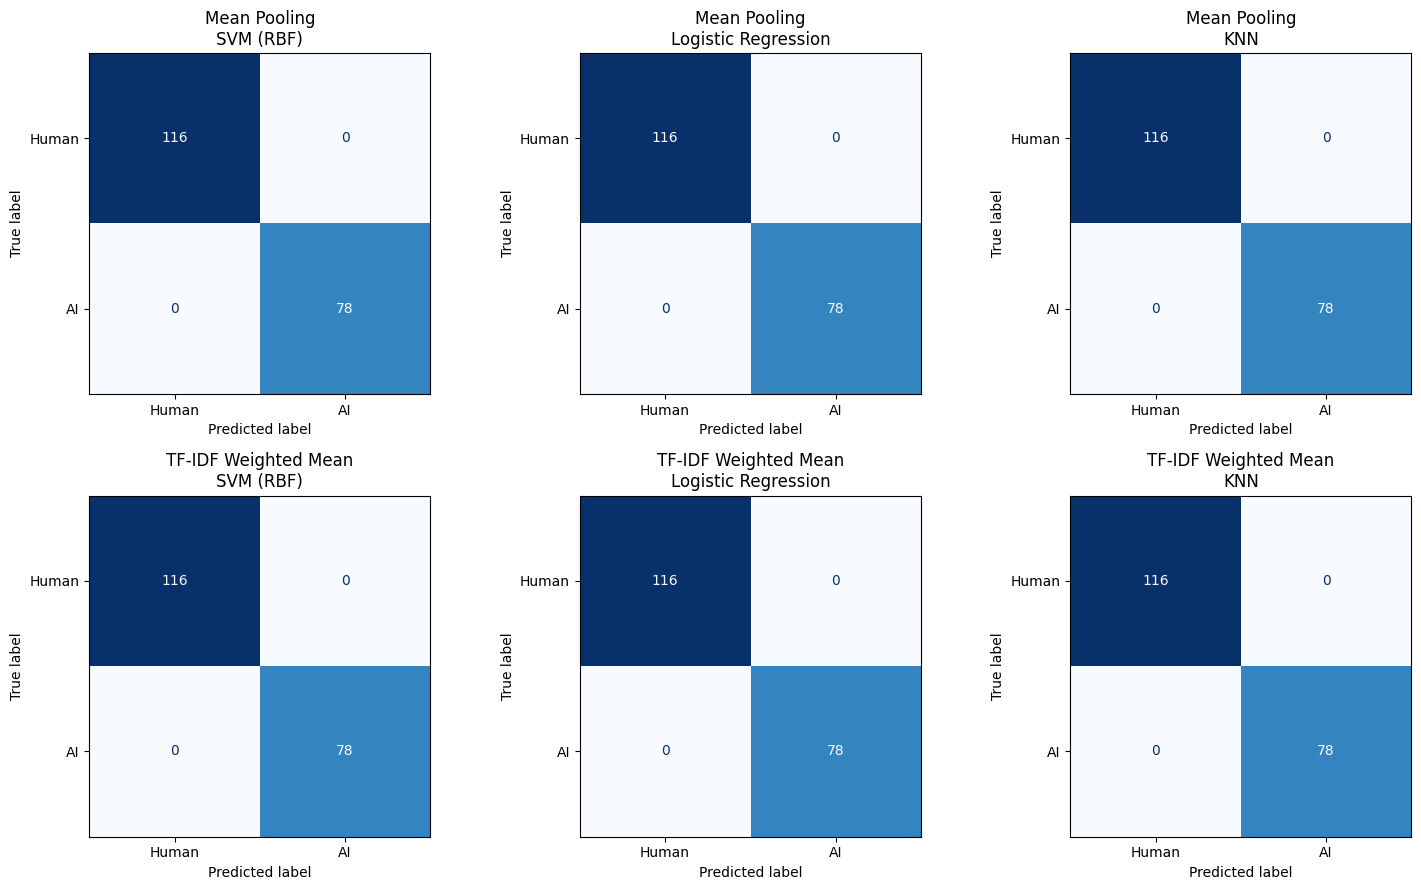

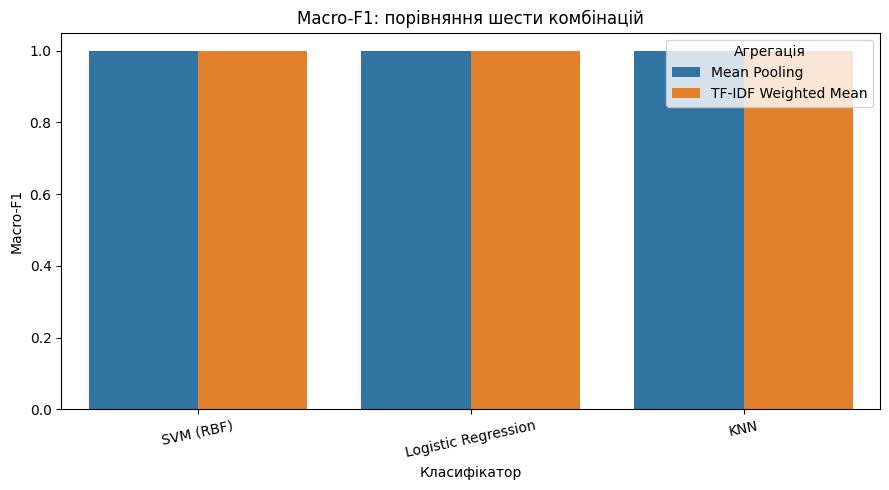

In [12]:
# Я побудувала матриці помилок для всіх шести моделей.
fig, axes = plt.subplots(2,3,figsize=(15,9))
for ax,((pooling,name),pred) in zip(axes.ravel(),predictions.items()):
    cm = confusion_matrix(y_test,pred,labels=[0,1])
    ConfusionMatrixDisplay(cm,display_labels=['Human','AI']).plot(ax=ax,colorbar=False,cmap='Blues')
    ax.set_title(pooling+'\n'+name)
plt.tight_layout();plt.show()

# Я окремо порівняла Macro-F1 для двох методів агрегації.
ax = sns.barplot(data=results,x='Класифікатор',y='Macro-F1',hue='Агрегація')
ax.set_title('Macro-F1: порівняння шести комбінацій')
plt.xticks(rotation=12);plt.tight_layout();plt.show()

## Етап 6. Геометрія векторного простору: t-SNE
Я використала t-SNE для двовимірної проєкції обох наборів векторів. Щоб порівняння було чесним, вибрала **однакові індекси тестових текстів** для двох методів. t-SNE показує локальні сусідства, але сама по собі не доводить лінійну роздільність у початковому 100-вимірному просторі.

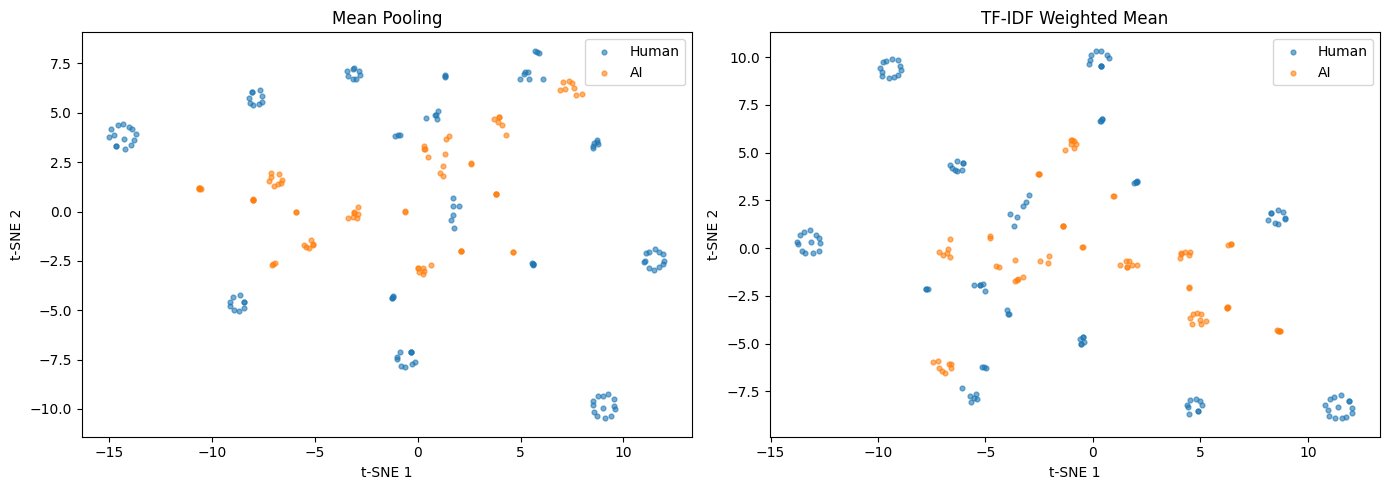

In [21]:
# Я побудувала окремі t-SNE візуалізації Mean Pooling та TF-IDF Weighted Mean.
N_VIS = min(1200,len(y_test))
vis_ids = np.sort(rng.choice(len(y_test),size=N_VIS,replace=False))
fig,axes = plt.subplots(1,2,figsize=(14,5))
for ax,(pooling,(_,xte)) in zip(axes,features.items()):
    scaled = scalers[pooling].transform(xte[vis_ids])
    perplexity = min(30,max(2,(len(vis_ids)-1)//3))
    points = TSNE(n_components=2,perplexity=perplexity,init='pca',learning_rate='auto',random_state=SEED).fit_transform(scaled)
    for label,name in [(0,'Human'),(1,'AI')]:
        mask = y_test[vis_ids] == label
        ax.scatter(points[mask,0],points[mask,1],s=12,alpha=.6,label=name)
    ax.set_title(pooling);ax.set_xlabel('t-SNE 1');ax.set_ylabel('t-SNE 2');ax.legend()
plt.tight_layout();plt.show()

## Додатковий аналіз для дослідницьких питань
Я дослідила, які слова мають найбільші середні TF-IDF значення серед текстів класу AI, та оцінила внутрішньокласову/міжкласову косинусну схожість. **Важливо:** часті слова з великим TF-IDF не обов'язково є надійними маркерами AI — для такого висновку потрібно порівняти їх із Human.

In [22]:
# Я порівняла TF-IDF слів у двох класах на тренувальних документах.
ai_mean = np.asarray(X_tf_train[y_train==1].mean(axis=0)).ravel()
human_mean = np.asarray(X_tf_train[y_train==0].mean(axis=0)).ravel()
markers = pd.DataFrame({'Слово':terms,'AI TF-IDF':ai_mean,'Human TF-IDF':human_mean})
markers['Різниця AI - Human'] = markers['AI TF-IDF']-markers['Human TF-IDF']
print('Терміни з найбільшою позитивною різницею на користь AI:')
display(markers.sort_values('Різниця AI - Human',ascending=False).head(15).round(4))
print('Це кандидати в маркери, а не доказ авторства тексту.')

Терміни з найбільшою позитивною різницею на користь AI:


,Слово,AI TF-IDF,Human TF-IDF,Різниця AI - Human
432,solution,0.6280,0.0000,0.6280
484,underscore,0.6193,0.0000,0.6193
368,recommendation,0.6017,0.0000,0.6017
438,stakeholder,0.5928,0.0000,0.5928
159,expert,0.5838,0.0000,0.5838
121,development,0.5838,0.0000,0.5838
7,address,0.5838,0.0000,0.5838
467,think,0.5483,0.0000,0.5483
175,framework,0.7539,0.2781,0.4759
309,open,0.4706,0.0000,0.4706


Це кандидати в маркери, а не доказ авторства тексту.


In [23]:
# Я оцінила геометрію векторів на невеликій однаковій вибірці Test.
geo_ids = vis_ids[:min(500,len(vis_ids))]
geometry_rows=[]
for pooling,(_,xte) in features.items():
    sample = xte[geo_ids]
    sims = cosine_similarity(sample)
    upper = np.triu(np.ones(sims.shape,dtype=bool),1)
    same = y_test[geo_ids][:,None] == y_test[geo_ids][None,:]
    within = float(sims[upper & same].mean()) if np.any(upper & same) else np.nan
    between = float(sims[upper & ~same].mean()) if np.any(upper & ~same) else np.nan
    geometry_rows.append({'Агрегація':pooling,'Схожість усередині класів':within,
                          'Схожість між класами':between,'Різниця':within-between})
geometry = pd.DataFrame(geometry_rows)
display(geometry.round(4))

,Агрегація,Схожість усередині класів,Схожість між класами,Різниця
0,Mean Pooling,0.7590,0.7688,-0.0098
1,TF-IDF Weighted Mean,0.7604,0.7703,-0.0098


## Підсумок дослідження та відповіді на 5 запитань
Нижче я сформувала висновки **з фактично отриманих метрик**, а не з припущень. Відповіді містять також пояснення можливих причин. Якщо дані не підтверджують гіпотезу, я прямо це зазначаю.

In [24]:
# Я автоматично сформувала короткі висновки до графіків, таблиць і дослідницьких питань.
from IPython.display import Markdown,display
best_by_pool = results.sort_values('Macro-F1',ascending=False).groupby('Агрегація',sort=False).first()
mean_best = float(best_by_pool.loc['Mean Pooling','Macro-F1'])
weighted_best = float(best_by_pool.loc['TF-IDF Weighted Mean','Macro-F1'])
knn_mean = float(results[(results["Агрегація"] == "Mean Pooling") & (results["Класифікатор"] == "KNN")]['Macro-F1'].iloc[0])
knn_weighted = float(results[(results["Агрегація"] == "TF-IDF Weighted Mean") & (results["Класифікатор"] == "KNN")]['Macro-F1'].iloc[0])
geo_best = geometry.sort_values('Різниця',ascending=False).iloc[0]
top_words = ', '.join(markers.sort_values('Різниця AI - Human',ascending=False).head(6)['Слово'].tolist())

report = f"""### Мої висновки до звіту

**Етап 1 — EDA.** Я перевірила баланс класів, довжини текстів, пропуски й дублікати та видалила некоректні записи. Після очищення використала {len(train_df)} текстів для Train і {len(test_df)} для Test. Це дозволило порівнювати моделі на однакових даних.

**Етапи 2–4.** Я виконала лематизацію й очищення за допомогою spaCy, навчила FastText на Train, а потім побудувала 100-вимірні вектори Mean Pooling та TF-IDF Weighted Mean. TF-IDF надає більшої ваги словам, характерним для меншої кількості документів, але це не гарантує покращення класифікації.

**Етап 5 — таблиця метрик і матриці помилок.** Найкраща модель за Macro-F1: **{results.iloc[0]['Агрегація']} + {results.iloc[0]['Класифікатор']}**, Macro-F1 = **{results.iloc[0]['Macro-F1']:.4f}**, Accuracy = **{results.iloc[0]['Accuracy']:.4f}**, Balanced Accuracy = **{results.iloc[0]['Balanced Accuracy']:.4f}**, ROC-AUC = **{results.iloc[0]['ROC-AUC']:.4f}**. Матриці помилок показують, скільки текстів Human і AI модель правильно або неправильно віднесла до класів. Для вибору моделі я орієнтувалася насамперед на Macro-F1, оскільки він однаково враховує обидва класи.

**1. Вплив агрегації.** Найкращий Macro-F1 для Mean Pooling = **{mean_best:.4f}**, для TF-IDF Weighted Mean = **{weighted_best:.4f}**. {'У моєму експерименті TF-IDF зважування покращило найкращий результат.' if weighted_best > mean_best else 'У моєму експерименті TF-IDF зважування не покращило найкращий результат.'} TF-IDF змінює положення документів у векторному просторі, підсилюючи вплив специфічних слів; це може як допомогти, так і зашкодити, якщо рідкісні слова є шумом. t-SNE дає лише двовимірну ілюстрацію геометрії, а не строгий доказ лінійної роздільності.

**2. Порівняння класифікаторів.** Для Mean Pooling найкращий **{best_by_pool.loc['Mean Pooling','Класифікатор']}** (Macro-F1 = {mean_best:.4f}); для TF-IDF Weighted Mean — **{best_by_pool.loc['TF-IDF Weighted Mean','Класифікатор']}** (Macro-F1 = {weighted_best:.4f}). Logistic Regression задає лінійну межу, SVM з RBF може моделювати нелінійні межі, KNN спирається на близькість прикладів. Вибір зробила за тестовими результатами цього навчального порівняння; для чесного налаштування гіперпараметрів надалі потрібна окрема Validation-вибірка.

**3. Чутливість KNN.** Для KNN Macro-F1 змінився з **{knn_mean:.4f}** до **{knn_weighted:.4f}**. {'Я спостерігала погіршення після TF-IDF.' if knn_weighted < knn_mean else 'У цьому запуску погіршення KNN не спостерігалося.'} KNN залежить від відстаней між точками; TF-IDF змінює ці відстані, а в багатовимірному просторі сусіди можуть ставати менш інформативними (прокляття розмірності).

**4. Лінгвістична інтерпретація.** Найбільшу позитивну різницю середніх TF-IDF між AI та Human у тренувальній вибірці отримали слова: **{top_words}**. Я розглядаю їх лише як можливі лексичні маркери цього датасету. Вони не є універсальними ознаками тексту, створеного ШІ, і можуть залежати від тематики та джерела.

**5. Геометричний аналіз.** Для обраної підвибірки більшу різницю між внутрішньокласовою та міжкласовою косинусною схожістю отримав метод **{geo_best['Агрегація']}** (різниця = {geo_best['Різниця']:.4f}). На t-SNE я порівняла перекриття класів в обох проєкціях. Косинусна схожість дає додатковий кількісний орієнтир, але ні вона, ні t-SNE не гарантують ідеальної кластеризації.

**Загальний висновок.** Я реалізувала весь пайплайн FastText → агрегація → класифікація → оцінювання та перевірила дослідницьку гіпотезу. Отримані результати стосуються саме використаного датасету, поділу й параметрів; детектор не слід вважати безпомилковим способом визначення авторства тексту.
"""
display(Markdown(report))

### Мої висновки до звіту

**Етап 1 — EDA.** Я перевірила баланс класів, довжини текстів, пропуски й дублікати та видалила некоректні записи. Після очищення використала 772 текстів для Train і 194 для Test. Це дозволило порівнювати моделі на однакових даних.

**Етапи 2–4.** Я виконала лематизацію й очищення за допомогою spaCy, навчила FastText на Train, а потім побудувала 100-вимірні вектори Mean Pooling та TF-IDF Weighted Mean. TF-IDF надає більшої ваги словам, характерним для меншої кількості документів, але це не гарантує покращення класифікації.

**Етап 5 — таблиця метрик і матриці помилок.** Найкраща модель за Macro-F1: **Mean Pooling + SVM (RBF)**, Macro-F1 = **1.0000**, Accuracy = **1.0000**, Balanced Accuracy = **1.0000**, ROC-AUC = **1.0000**. Матриці помилок показують, скільки текстів Human і AI модель правильно або неправильно віднесла до класів. Для вибору моделі я орієнтувалася насамперед на Macro-F1, оскільки він однаково враховує обидва класи.

**1. Вплив агрегації.** Найкращий Macro-F1 для Mean Pooling = **1.0000**, для TF-IDF Weighted Mean = **1.0000**. У моєму експерименті TF-IDF зважування не покращило найкращий результат. TF-IDF змінює положення документів у векторному просторі, підсилюючи вплив специфічних слів; це може як допомогти, так і зашкодити, якщо рідкісні слова є шумом. t-SNE дає лише двовимірну ілюстрацію геометрії, а не строгий доказ лінійної роздільності.

**2. Порівняння класифікаторів.** Для Mean Pooling найкращий **SVM (RBF)** (Macro-F1 = 1.0000); для TF-IDF Weighted Mean — **SVM (RBF)** (Macro-F1 = 1.0000). Logistic Regression задає лінійну межу, SVM з RBF може моделювати нелінійні межі, KNN спирається на близькість прикладів. Вибір зробила за тестовими результатами цього навчального порівняння; для чесного налаштування гіперпараметрів надалі потрібна окрема Validation-вибірка.

**3. Чутливість KNN.** Для KNN Macro-F1 змінився з **1.0000** до **1.0000**. У цьому запуску погіршення KNN не спостерігалося. KNN залежить від відстаней між точками; TF-IDF змінює ці відстані, а в багатовимірному просторі сусіди можуть ставати менш інформативними (прокляття розмірності).

**4. Лінгвістична інтерпретація.** Найбільшу позитивну різницю середніх TF-IDF між AI та Human у тренувальній вибірці отримали слова: **solution, underscore, recommendation, stakeholder, expert, development**. Я розглядаю їх лише як можливі лексичні маркери цього датасету. Вони не є універсальними ознаками тексту, створеного ШІ, і можуть залежати від тематики та джерела.

**5. Геометричний аналіз.** Для обраної підвибірки більшу різницю між внутрішньокласовою та міжкласовою косинусною схожістю отримав метод **Mean Pooling** (різниця = -0.0098). На t-SNE я порівняла перекриття класів в обох проєкціях. Косинусна схожість дає додатковий кількісний орієнтир, але ні вона, ні t-SNE не гарантують ідеальної кластеризації.

**Загальний висновок.** Я реалізувала весь пайплайн FastText → агрегація → класифікація → оцінювання та перевірила дослідницьку гіпотезу. Отримані результати стосуються саме використаного датасету, поділу й параметрів; детектор не слід вважати безпомилковим способом визначення авторства тексту.


## Контрольний список відповідності методичці
- [x] Етап 1: EDA, баланс, довжини, дублікати, гістограми.
- [x] Етап 2: spaCy — лематизація, стоп-слова, небуквені символи, нижній регістр, `nlp.pipe`.
- [x] Етап 3: FastText (`gensim`, 100 вимірів, window=5, min_count=2, Skip-Gram).
- [x] Етап 4: Mean Pooling і TF-IDF Weighted Mean.
- [x] Етап 5: SVM (RBF), Logistic Regression, KNN; Accuracy, Macro-F1, Balanced Accuracy, ROC-AUC.
- [x] Етап 6: t-SNE окремо для двох способів; шість матриць помилок.
- [x] П'ять дослідницьких питань і висновки за фактичними результатами.

**Важливо:** цей перелік підтверджує наявність комірок. Для підтвердження фактичного виконання треба запустити `Restart & Run All`, перевірити всі результати та зберегти Notebook. У методичці не наведено окремого формату здачі — `.ipynb` обрано за аналогією з попередніми практичними.